In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
import pandas as pd
import datetime

In [3]:
import yfinance as yf

In [5]:
aapl = yf.Ticker("aapl")

In [6]:
dataset = aapl.history(start = "2015-01-01", end = datetime.datetime.now())

In [7]:
dataset.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2015-01-02 00:00:00-05:00,24.648443,24.659508,23.754470,24.192606,212818400,0.0,0.0
2015-01-05 00:00:00-05:00,23.962469,24.042131,23.325182,23.511057,257142000,0.0,0.0
2015-01-06 00:00:00-05:00,23.575226,23.772165,23.152579,23.513268,263188400,0.0,0.0
2015-01-07 00:00:00-05:00,23.721282,23.942563,23.610642,23.842987,160423600,0.0,0.0
2015-01-08 00:00:00-05:00,24.170479,24.816618,24.053199,24.759085,237458000,0.0,0.0


In [8]:
tstart = 2019
tend = 2023

In [9]:
training_set = dataset.loc[f'{tstart}':f'{tend}', ['Close']]
test_set = dataset.loc[f'{tend+1}':, ['Close']]

In [10]:
training_set.head()

,Close
Date,
2019-01-02 00:00:00-05:00,37.469204
2019-01-03 00:00:00-05:00,33.736996
2019-01-04 00:00:00-05:00,35.177204
2019-01-07 00:00:00-05:00,35.098900
2019-01-08 00:00:00-05:00,35.768002


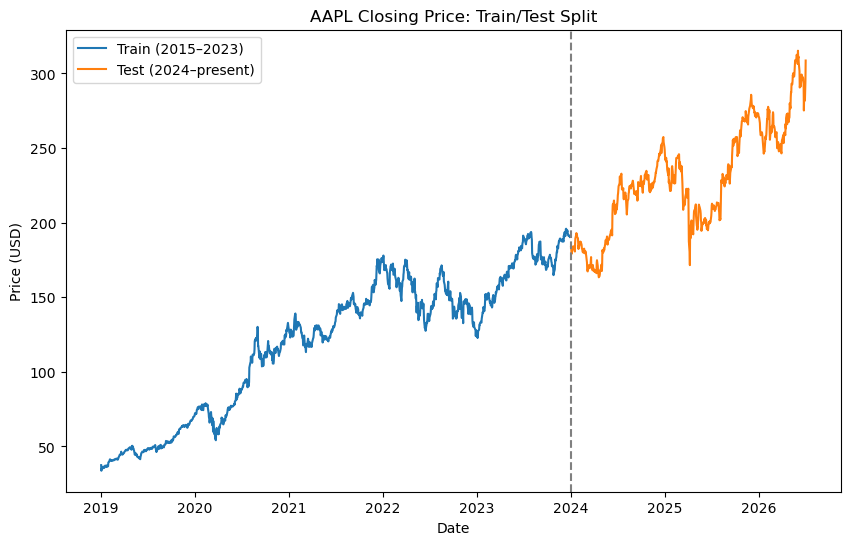

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(training_set.index, training_set['Close'], label='Train (2015–2023)')
plt.plot(test_set.index, test_set['Close'], label='Test (2024–present)')
plt.axvline(x=test_set.index[0], color='gray', linestyle='--')
plt.title('AAPL Closing Price: Train/Test Split')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

In [12]:
def create_dataset(dataset, lookback):
    """Transform a time series into a prediction dataset
    
    Args:
        dataset: A numpy array of time series, first dimension is the time steps
        lookback: Size of window for prediction
    """
    X, y = [], []
    for i in range(len(dataset)-lookback):
        feature = dataset[i:i+lookback]
        target = dataset[i+1:i+lookback+1]
        X.append(feature)
        y.append(target)
    return torch.tensor(np.array(X)), torch.tensor(np.array(y))

In [13]:
from sklearn.preprocessing import MinMaxScaler

sc = MinMaxScaler(feature_range=(0, 1))
training_set_scaled = sc.fit_transform(training_set)   # fit only on train
test_set_scaled = sc.transform(test_set)                # reuse same scaler on test

In [14]:
train_array = training_set_scaled.astype('float32')
test_array = test_set_scaled.astype('float32')

In [15]:
lookback = 60

X_train, y_train = create_dataset(train_array, lookback)
X_test, y_test = create_dataset(test_array, lookback)

In [16]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([1198, 60, 1]) torch.Size([1198, 60, 1])
torch.Size([567, 60, 1]) torch.Size([567, 60, 1])


In [23]:
class AppleModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.ltsm = nn.LSTM(input_size = 1, hidden_size = 50, num_layers = 1, batch_first =True)
        self.linear = nn.Linear(50, 1)
    def forward(self, x):
        x, _ = self.ltsm(x)
        x = self.linear(x)
        return x

In [24]:
# training and verifying

model = AppleModel()
optimizer = optim.Adam(model.parameters())
loss_fn = nn.MSELoss()
loader = data.DataLoader(data.TensorDataset(X_train, y_train), shuffle = True, batch_size = 8)

n_epochs = 2000
for epoch in range(n_epochs):
    model.train()
    for X_batch, y_batch in loader:
        y_pred = model(X_batch)
        loss = loss_fn(y_pred, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    # validation
    if epoch % 100 != 0:
        continue
    model.eval()
    with torch.no_grad():
        y_pred = model(X_train)
        train_rmse = np.sqrt(loss_fn(y_pred, y_train))
        y_pred = model(X_test)
        test_rmse = np.sqrt(loss_fn(y_pred, y_test))
    print("Epoch %d: train RMSE %.4f, test RMSE %.4f" % (epoch, train_rmse, test_rmse))

Epoch 0: train RMSE 0.0868, test RMSE 0.1864
Epoch 100: train RMSE 0.0151, test RMSE 0.0282
Epoch 200: train RMSE 0.0152, test RMSE 0.0644
Epoch 300: train RMSE 0.0113, test RMSE 0.0651
Epoch 400: train RMSE 0.0085, test RMSE 0.0747
Epoch 500: train RMSE 0.0079, test RMSE 0.0571
Epoch 600: train RMSE 0.0072, test RMSE 0.0698
Epoch 700: train RMSE 0.0068, test RMSE 0.0856
Epoch 800: train RMSE 0.0066, test RMSE 0.1095
Epoch 900: train RMSE 0.0064, test RMSE 0.1246
Epoch 1000: train RMSE 0.0061, test RMSE 0.1268
Epoch 1100: train RMSE 0.0060, test RMSE 0.1264
Epoch 1200: train RMSE 0.0058, test RMSE 0.1297
Epoch 1300: train RMSE 0.0058, test RMSE 0.1322
Epoch 1400: train RMSE 0.0058, test RMSE 0.1284
Epoch 1500: train RMSE 0.0055, test RMSE 0.1230
Epoch 1600: train RMSE 0.0054, test RMSE 0.1151
Epoch 1700: train RMSE 0.0053, test RMSE 0.1110
Epoch 1800: train RMSE 0.0053, test RMSE 0.1048
Epoch 1900: train RMSE 0.0053, test RMSE 0.1082


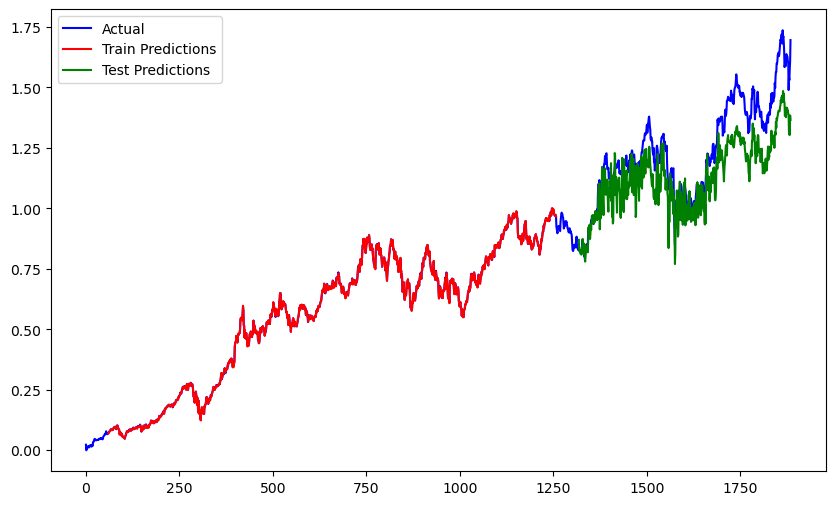

In [25]:
timeseries = np.concatenate([train_array, test_array])
train_size = len(train_array)

with torch.no_grad():
    # shift train predictions for plotting
    train_plot = np.ones_like(timeseries) * np.nan
    y_pred = model(X_train)[:, -1, :].numpy()
    train_plot[lookback:train_size] = y_pred

    # shift test predictions for plotting
    test_plot = np.ones_like(timeseries) * np.nan
    y_pred = model(X_test)[:, -1, :].numpy()
    test_plot[train_size+lookback:len(timeseries)] = y_pred

# plot
plt.figure(figsize=(10, 6))
plt.plot(timeseries, c='b', label='Actual')
plt.plot(train_plot, c='r', label='Train Predictions')
plt.plot(test_plot, c='g', label='Test Predictions')
plt.legend()
plt.show()

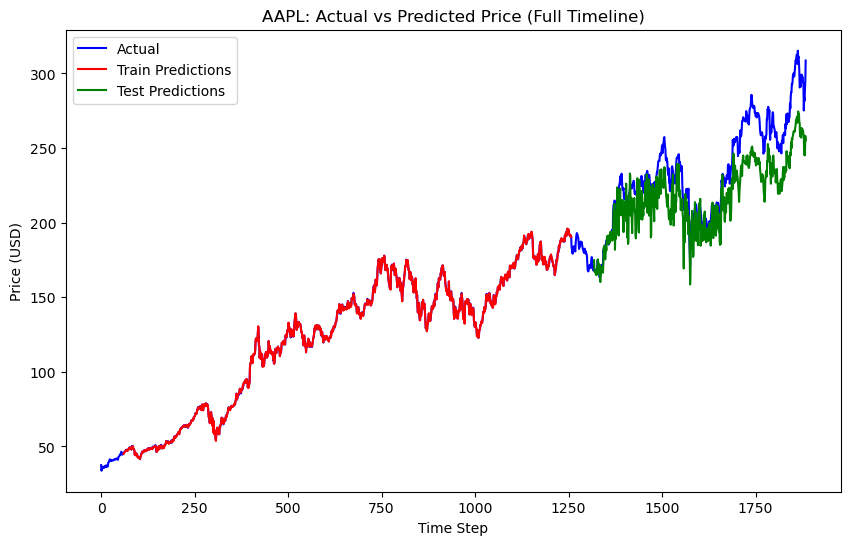

In [26]:
timeseries_prices = sc.inverse_transform(timeseries)
train_size = len(train_array)

train_plot = np.ones_like(timeseries_prices) * np.nan
with torch.no_grad():
    y_pred_train = model(X_train)[:, -1, :].numpy()
    y_pred_train_prices = sc.inverse_transform(y_pred_train)
    train_plot[lookback:train_size] = y_pred_train_prices

test_plot = np.ones_like(timeseries_prices) * np.nan
with torch.no_grad():
    y_pred_test = model(X_test)[:, -1, :].numpy()
    y_pred_test_prices = sc.inverse_transform(y_pred_test)
    test_plot[train_size+lookback:len(timeseries_prices)] = y_pred_test_prices

plt.figure(figsize=(10, 6))
plt.plot(timeseries_prices, c='b', label='Actual')
plt.plot(train_plot, c='r', label='Train Predictions')
plt.plot(test_plot, c='g', label='Test Predictions')
plt.xlabel('Time Step')
plt.ylabel('Price (USD)')
plt.title('AAPL: Actual vs Predicted Price (Full Timeline)')
plt.legend()
plt.show()

In [27]:
torch.save(model.state_dict(), "model_proj2.pth")